In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv('dataset/cardio_train.csv',sep=';')

In [20]:
df = df.drop(columns=['id'])
df.head()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [21]:
new_data = df.copy()

In [22]:
new_data

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [23]:
new_data['age'] = (new_data['age']/365.25).astype(int)

In [24]:
new_data.isnull().sum()

age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [25]:
new_data.describe()

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,52.803257,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,6.762462,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,29.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,53.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,58.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,64.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


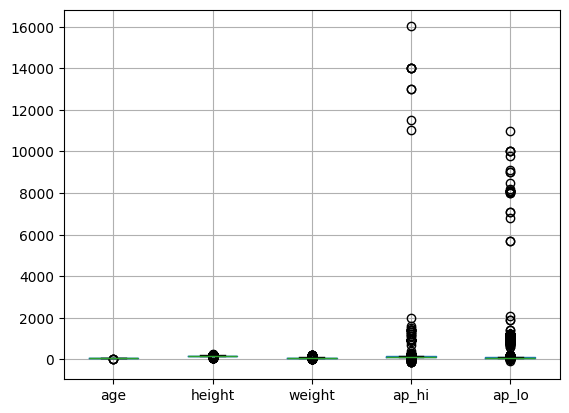

In [26]:
new_data[['age','height','weight','ap_hi','ap_lo']].boxplot()
plt.show()

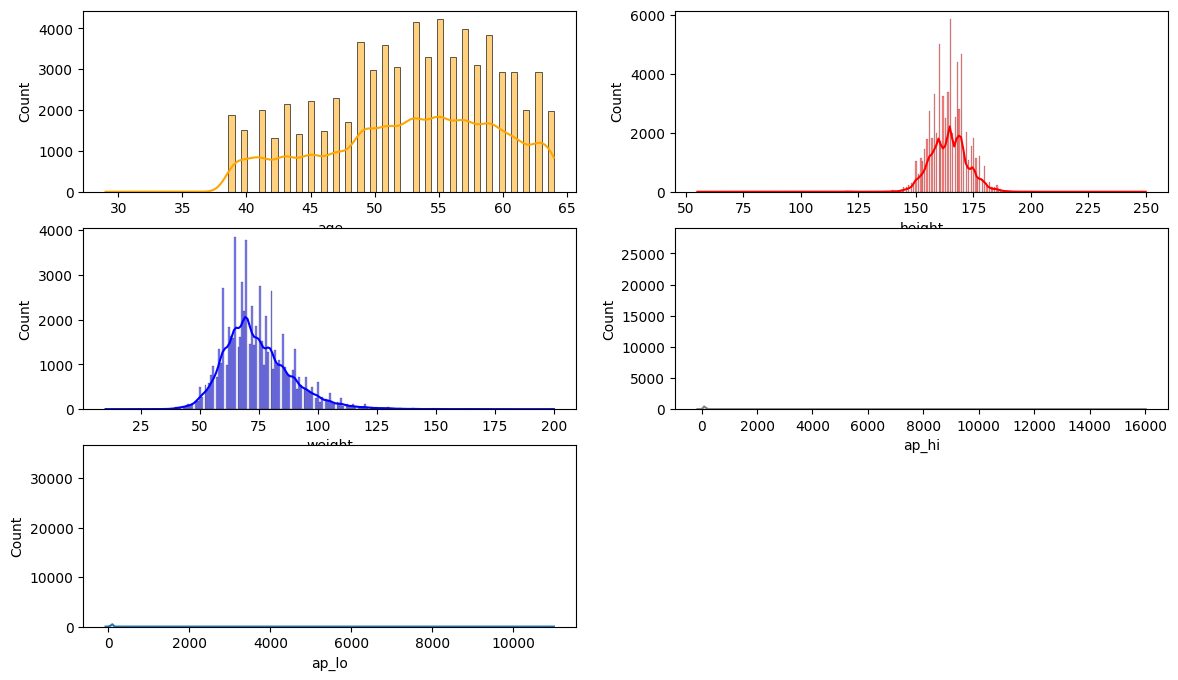

In [27]:
plt.figure(figsize=(14,8))
plt.subplot(3,2,1)
sns.histplot(new_data['age'],kde=True,color='orange')
plt.subplot(3,2,2)
sns.histplot(new_data['height'],kde=True,color='red')
plt.subplot(3,2,3)
sns.histplot(new_data['weight'],kde=True,color='blue')
plt.subplot(3,2,4)
sns.histplot(new_data['ap_hi'],kde=True,color='gray')
plt.subplot(3,2,5)
sns.histplot(new_data['ap_lo'],kde=True)
plt.show()

In [28]:
age_Q1 = new_data['age'].quantile(0.25)
age_Q3 = new_data['age'].quantile(0.75)
age_IQR = age_Q3-age_Q1
minimum_age = age_Q1-1.5*age_IQR
maximum_age = age_Q3+1.5*age_IQR

new_data['age'] = np.where(
    new_data['age']<minimum_age,
    minimum_age,
    np.where(
        new_data['age']>maximum_age,
        maximum_age,
        new_data['age']
    )
)

In [29]:
height_Q1 = new_data['height'].quantile(0.25)
height_Q3 = new_data['height'].quantile(0.75)
height_IQR = height_Q3-height_Q1
minimum_height = height_Q1-1.5*height_IQR
maximum_height = height_Q3+1.5*height_IQR

new_data['height'] = np.where(
    new_data['height']<minimum_height,
    minimum_height,
    np.where(
        new_data['height']>maximum_height,
        maximum_height,
        new_data['height']
    )
)

In [30]:
weight_Q1 = new_data['weight'].quantile(0.25)
weight_Q3 = new_data['weight'].quantile(0.75)
weight_IQR = weight_Q3-weight_Q1
minimum_weight = weight_Q1-1.5*weight_IQR
maximum_weight = weight_Q3+1.5*weight_IQR

new_data['weight'] = np.where(
    new_data['weight']<minimum_weight,
    minimum_weight,
    np.where(
        new_data['weight']>maximum_weight,
        maximum_weight,
        new_data['weight']
    )
)

In [31]:
new_data[new_data['ap_hi']<new_data['ap_lo']].shape

(1234, 12)

In [33]:
data = new_data['ap_hi']<new_data['ap_lo']

new_data.loc[data,['ap_hi','ap_lo']] = new_data.loc[data,['ap_lo','ap_hi']].values

In [34]:
new_data[new_data['ap_hi']<new_data['ap_lo']].shape

(0, 12)

In [35]:
ap_hi_Q1 = new_data['ap_hi'].quantile(0.25)
ap_hi_Q3 = new_data['ap_hi'].quantile(0.75)
ap_hi_IQR = ap_hi_Q3-ap_hi_Q1
minimum_ap_hi = ap_hi_Q1-1.5*ap_hi_IQR
maximum_ap_hi = ap_hi_Q3+1.5*ap_hi_IQR

new_data['ap_hi'] = np.where(
    new_data['ap_hi']<minimum_ap_hi,
    minimum_ap_hi,
    np.where(
        new_data['ap_hi']>maximum_ap_hi,
        maximum_ap_hi,
        new_data['ap_hi']
    )
)

In [36]:
ap_lo_Q1 = new_data['ap_lo'].quantile(0.25)
ap_lo_Q3 = new_data['ap_lo'].quantile(0.75)
ap_lo_IQR = ap_lo_Q3-ap_lo_Q1
minimum_ap_lo = ap_lo_Q1-1.5*ap_lo_IQR
maximum_ap_lo = ap_lo_Q3+1.5*ap_lo_IQR

new_data['ap_lo'] = np.where(
    new_data['ap_lo']<minimum_ap_lo,
    minimum_ap_lo,
    np.where(
        new_data['ap_lo']>maximum_ap_lo,
        maximum_ap_lo,
        new_data['ap_lo']
    )
)

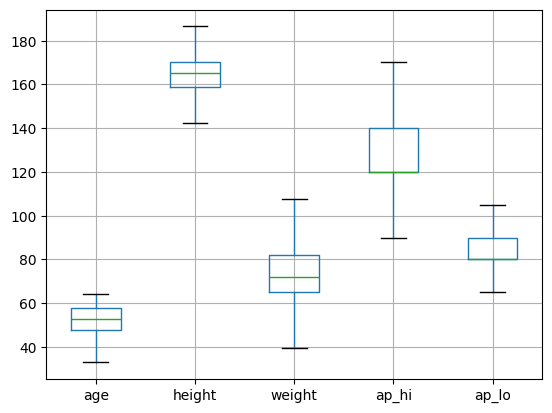

In [37]:
new_data[['age','height','weight','ap_hi','ap_lo']].boxplot()
plt.show()

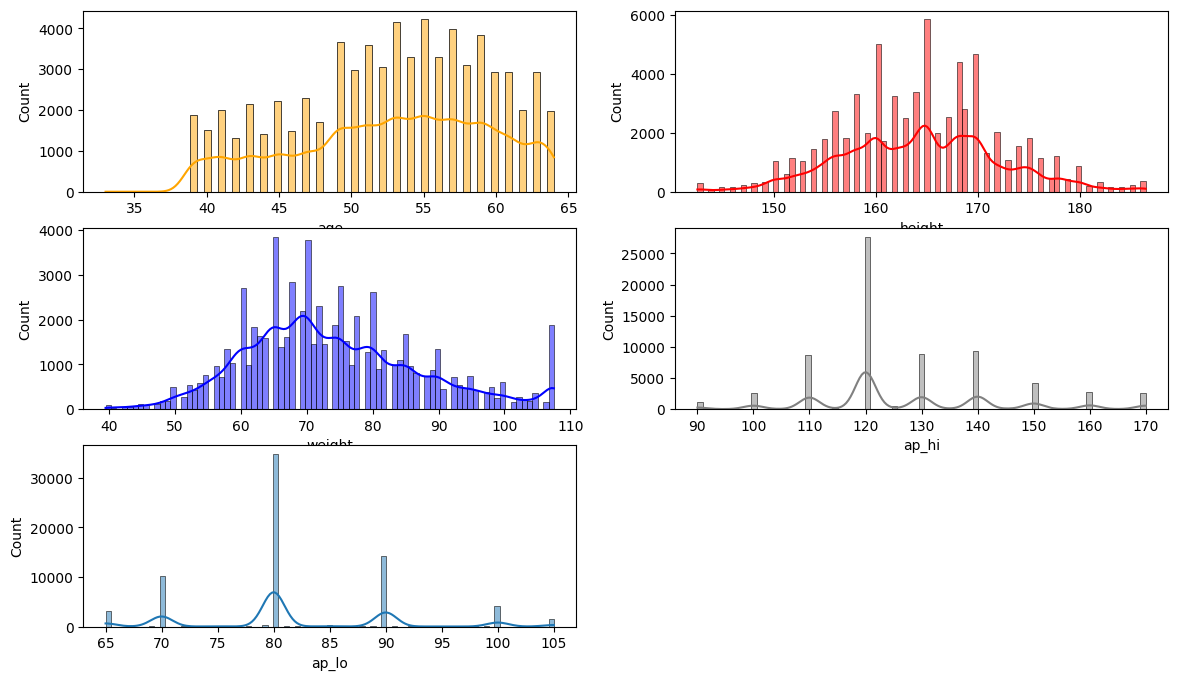

In [38]:
plt.figure(figsize=(14,8))
plt.subplot(3,2,1)
sns.histplot(new_data['age'],kde=True,color='orange')
plt.subplot(3,2,2)
sns.histplot(new_data['height'],kde=True,color='red')
plt.subplot(3,2,3)
sns.histplot(new_data['weight'],kde=True,color='blue')
plt.subplot(3,2,4)
sns.histplot(new_data['ap_hi'],kde=True,color='gray')
plt.subplot(3,2,5)
sns.histplot(new_data['ap_lo'],kde=True)
plt.show()

In [41]:
new_data.to_csv('dataset/preprocessed_data.csv',index=False)